# 07 · Mock SBI with SNLE

NLE trained on the pasted responses, evaluated on the noiseless pasted mock observation.
NLE and not NPE: it learns `p(x | theta)` and applies the box prior analytically at MCMC
time, so the design never enters the estimated object and there is no proposal correction
to get wrong.

`oracle_mock_selfconsistent_test.py` (builds the score operator) · `run_mock_sbi_snle.py` ·
`plot_three_way_triangle.py`

In [3]:
import json, os, pathlib, sys
import numpy as np, h5py
import matplotlib.pyplot as plt
_cwd = pathlib.Path.cwd().resolve()
_root_candidates = ([pathlib.Path(os.environ["GODMAX_REPO"]).expanduser()]
                    if os.environ.get("GODMAX_REPO") else [])
_root_candidates += [_cwd, *_cwd.parents,
                     pathlib.Path("/work/hdd/bdne/aacharya2/GODMAX"),
                     pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX")]
ROOT = next((p.resolve() for p in _root_candidates
             if (p / "notebooks/SBI_validate").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Cannot locate GODMAX; set GODMAX_REPO to the checkout root")
sys.path.insert(0, str(ROOT / "notebooks/SBI_validate/common"))
DATA = ROOT / "data/SBI_validate"
VAL  = DATA / "three_probe_mock/validation"
INF  = DATA / "three_probe_inference"
MSBI = DATA / "mock_sbi"
BLUE, ORANGE, GREEN, INK2, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#dedcd6"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.edgecolor": GRID, "xtick.color": INK2, "ytick.color": INK2,
                     "font.size": 10.5, "axes.spines.top": False, "axes.spines.right": False})
SPECTRA = ["gy", "gkappa", "gtau"]
LBL = {"gg": r"$g \times g$", "gy": r"$g \times y$",
       "gkappa": r"$g \times \kappa_{\rm CMB}$", "gtau": r"$g \times \tau$"}
print("Done")

Done


In [2]:
PARAMS = ["theta_ej_0", "alpha_nt", "mu_beta", "theta_co_0", "nu_theta_ej_M"]
post = np.load(MSBI / "trial/mock_snle_n0038_posterior.npz", allow_pickle=True)
mock, u_mock = np.asarray(post["theta"]), np.asarray(post["u"])
man = json.loads(str(post["manifest_json"]))
print(f"{man['estimator']}  ->  {mock.shape[0]:,} samples")
print(f"  {man['n_pasted_points']} pasted points x "
      f"{man['n_training_rows']//man['n_pasted_points']} noise draws = "
      f"{man['n_training_rows']:,} rows")
print(f"  {man['seeds']} pooled network seeds; largest single-seed departure "
      f"{man['max_seed_departure_sigma']:.3f} sigma")
print(f"  proposal correction required: {man['proposal_correction_required']}")
print(f"  observation: {man['observation_kind']}")

SNLE (NLE, one round)  ->  80,000 samples
  94 pasted points x 64 noise draws = 6,016 rows
  4 pooled network seeds; largest single-seed departure 0.397 sigma
  proposal correction required: False
  observation: pasted_map_measurement_noiseless


### Seed-to-seed spread\n\nA single NLE seed is not quotable; the ensemble spread is the reason the run pools four.

orange line = the pooled mean


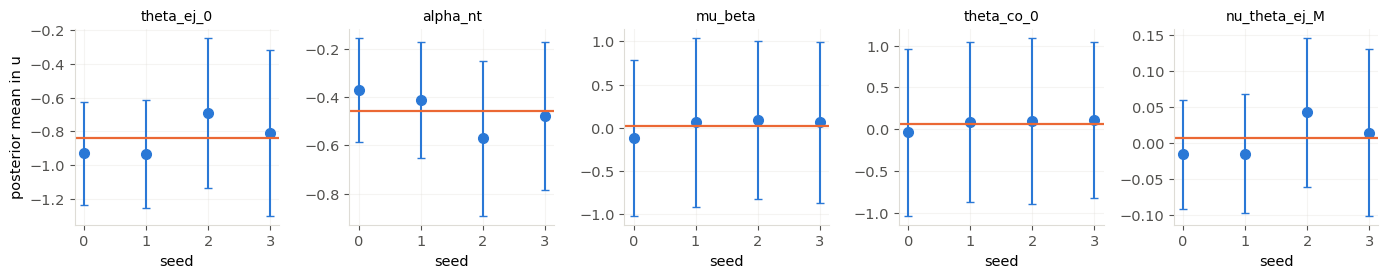

In [4]:
seeds = [np.asarray(post[f"u_seed_{i}"]) for i in range(man["seeds"])]
fig, axes = plt.subplots(1, 5, figsize=(14, 2.9))
for j, (ax, p) in enumerate(zip(axes, PARAMS)):
    for i, s in enumerate(seeds):
        ax.plot(i, s[:, j].mean(), "o", ms=7, color=BLUE)
        ax.errorbar(i, s[:, j].mean(), yerr=s[:, j].std(ddof=1), color=BLUE, capsize=3)
    ax.axhline(u_mock[:, j].mean(), color=ORANGE, lw=1.6)
    ax.set_title(p, fontsize=10); ax.set_xlabel("seed"); ax.set_xticks(range(len(seeds)))
    ax.grid(alpha=.3, color=GRID)
axes[0].set_ylabel("posterior mean in u")
fig.tight_layout()
print("orange line = the pooled mean")

### All three posteriors

In [5]:
# Constants are defined here rather than imported from plot_three_way_triangle.py:
# that module calls matplotlib.use("Agg") at import, which switches the backend away
# from the notebook's inline one and silently stops every later figure displaying.
TRUTH = np.array([2.0, 0.18, 0.6, 0.05, 0.0])
LABELS = [r"$\theta_{\rm ej,0}$", r"$\alpha_{\rm nt}$", r"$\mu_\beta$",
          r"$\theta_{\rm co,0}$", r"$\nu_{\theta_{\rm ej},M}$"]

In [6]:
raw = np.load(INF / "hmc_sc/run01/hmc_samples.npz")
hmc = np.stack([np.asarray(raw[f"sample_{p}"]).reshape(-1) for p in PARAMS], 1)
u_hmc = np.asarray(raw["u"]).reshape(-1, 5)
sbi = np.load(INF / "sbi_sc/run01/posterior_samples_round_4.npz")
npe, u_npe = np.asarray(sbi["theta"]), np.asarray(sbi["u"])

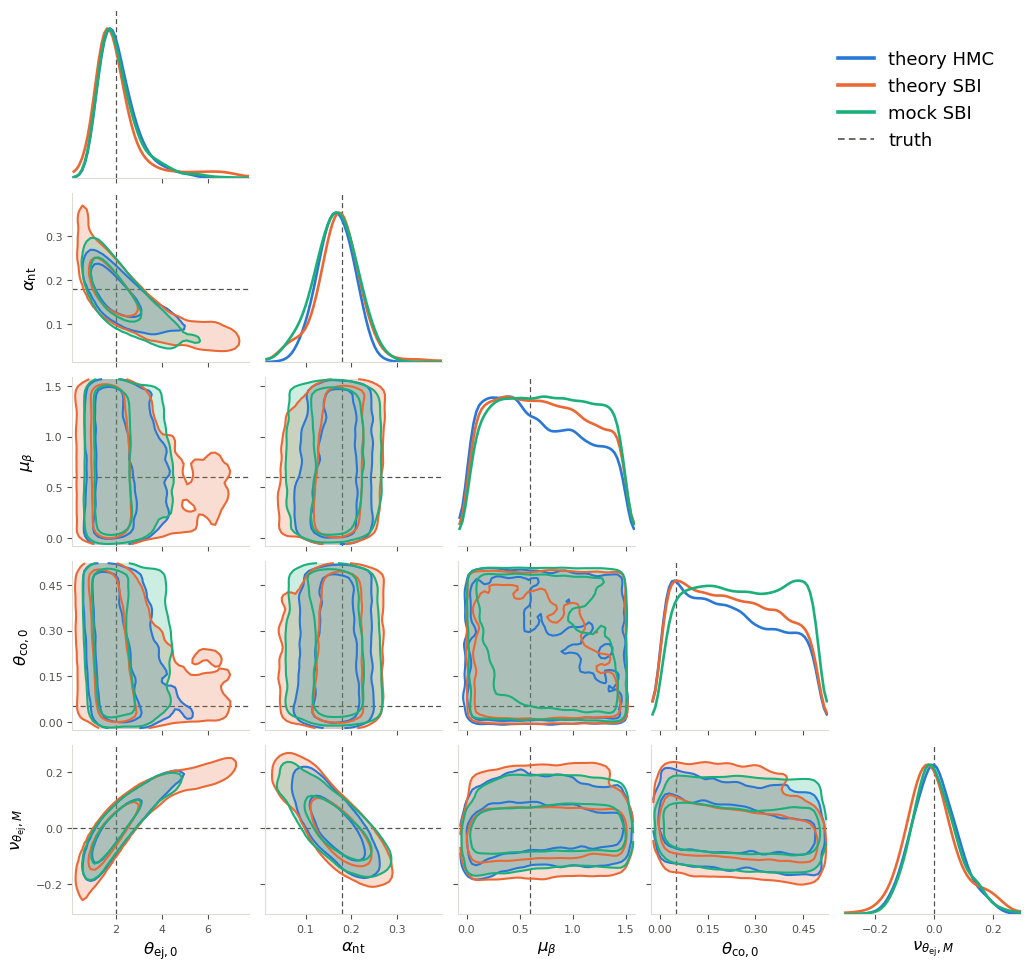

In [7]:
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D
def triangle(chains, colors, names, points=None):
    n, B1, S1, B2, S2 = 5, 64, 2.4, 44, 1.35
    lo, hi = np.empty(n), np.empty(n)
    for j in range(n):
        q = np.concatenate([np.percentile(c[:, j], [0.3, 99.7]) for c in chains])
        if points is not None: q = np.r_[q, points[:, j].min(), points[:, j].max()]
        pad = .06 * (q.max() - q.min()); lo[j], hi[j] = q.min() - pad, q.max() + pad
    fig, ax = plt.subplots(n, n, figsize=(10.6, 10.0))
    for i in range(n):
        for j in range(n):
            a = ax[i, j]
            if j > i: a.axis("off"); continue
            if i == j:
                for c, col in zip(chains, colors):
                    h, e = np.histogram(c[:, j], bins=B1, range=(lo[j], hi[j]), density=True)
                    h = gaussian_filter(h, S1); a.plot(.5*(e[:-1]+e[1:]), h/h.max(), color=col, lw=1.9)
                a.set_ylim(0, 1.13); a.set_yticks([]); a.spines["left"].set_visible(False)
            else:
                for kk, (c, col) in enumerate(zip(chains, colors)):
                    H, xe, ye = np.histogram2d(c[:, j], c[:, i], bins=B2,
                                               range=[[lo[j], hi[j]], [lo[i], hi[i]]])
                    H = gaussian_filter(H.T, S2)
                    if H.max() <= 0: continue
                    f = np.sort(H.ravel())[::-1]; cs = np.cumsum(f); cs /= cs[-1]
                    lv = sorted({float(f[min(int(np.searchsorted(cs, q)), f.size-1)])
                                 for q in (.68, .95)})
                    xc, yc = .5*(xe[:-1]+xe[1:]), .5*(ye[:-1]+ye[1:])
                    a.contourf(xc, yc, H, levels=lv+[H.max()*1.001], colors=col, alpha=.22, zorder=1+kk)
                    a.contour(xc, yc, H, levels=lv, colors=col, linewidths=1.5, zorder=5+kk)
                if points is not None:
                    a.plot(points[:, j], points[:, i], "o", ms=3.2, mfc="none", mec="k",
                           mew=.75, alpha=.85, zorder=20)
                a.set_ylim(lo[i], hi[i])
            a.axvline(TRUTH[j], color=INK2, lw=.9, ls=(0,(4,2.5)), zorder=0)
            if i != j: a.axhline(TRUTH[i], color=INK2, lw=.9, ls=(0,(4,2.5)), zorder=0)
            a.set_xlim(lo[j], hi[j]); a.tick_params(labelsize=8)
            a.xaxis.set_major_locator(plt.MaxNLocator(4, prune="both"))
            if i != j: a.yaxis.set_major_locator(plt.MaxNLocator(4, prune="both"))
            if i == n-1: a.set_xlabel(LABELS[j], fontsize=12)
            else: a.set_xticklabels([])
            if j == 0 and i > 0: a.set_ylabel(LABELS[i], fontsize=12)
            elif j != 0: a.set_yticklabels([])
    hs = [Line2D([], [], color=c, lw=2.6, label=nm) for c, nm in zip(colors, names)]
    if points is not None:
        hs.append(Line2D([], [], color="k", marker="o", ms=5, mfc="none", ls="none",
                         label="design points"))
    hs.append(Line2D([], [], color=INK2, lw=1.2, ls=(0,(4,2.5)), label="truth"))
    fig.legend(handles=hs, loc="upper right", bbox_to_anchor=(.975, .96), frameon=False,
               fontsize=13)
    fig.subplots_adjust(left=.09, right=.985, top=.985, bottom=.08, wspace=.09, hspace=.09)
    return fig
_ = triangle([hmc, npe, mock], [BLUE, ORANGE, GREEN],
             ["theory HMC", "theory SBI", "mock SBI"])

### Mean drift and 90% width ratio against theory HMC

In [7]:
w90 = lambda x: np.percentile(x, 95, 0) - np.percentile(x, 5, 0)
print(f"{'parameter':<16}{'SBI drift':>11}{'SBI w90':>9}{'mock drift':>12}{'mock w90':>10}")
for j, p in enumerate(PARAMS):
    print(f"{p:<16}"
          f"{(u_npe[:,j].mean()-u_hmc[:,j].mean())/u_hmc[:,j].std(ddof=1):>+11.3f}"
          f"{w90(u_npe)[j]/w90(u_hmc)[j]:>9.3f}"
          f"{(u_mock[:,j].mean()-u_hmc[:,j].mean())/u_hmc[:,j].std(ddof=1):>+12.3f}"
          f"{w90(u_mock)[j]/w90(u_hmc)[j]:>10.3f}")

parameter         SBI drift  SBI w90  mock drift  mock w90
theta_ej_0           -0.075    1.547      +0.014     1.086
alpha_nt             +0.089    1.415      -0.074     1.340
mu_beta              +0.105    0.977      +0.175     0.945
theta_co_0           +0.042    0.982      +0.233     0.964
nu_theta_ej_M        -0.130    1.223      +0.021     1.025


**Status.** This is the 94-point trial, not the full 128-point round. Against the relaxed
gate (0.20 sigma drift, 20% width) `theta_co_0` drift and `alpha_nt` width both fail;
`mu_beta` and `theta_co_0` are unconstrained by these three spectra (posterior sd ~= prior
sd), so their drifts are wobbles in a near-flat marginal. On widths, mock SBI is closer to
theory HMC than theory SBI is in four of five parameters.

---

## Exploratory (g^2X) SNLE pilot: 104 points × 5 map-level noise realisations

This section is deliberately separate from the two-point comparison above. It uses
`g2y[14], g2kappa[14], g2tau[14]` and the dedicated pilot observation/covariance/score
contract. The five-replica covariance and affine response are exploratory estimates:
these figures are an end-to-end diagnostic, not a validated or quotable Stage-7 result.

Expected inputs are made by `build_mock_sbi_g2x_pilot_contract.py` and
`run_mock_sbi_g2x_snle_pilot.py`. Figures are also saved below
`data/SBI_validate/mock_sbi/g2x_pilot_rep5/figures`.


In [8]:
G2_TRAINING = MSBI / "paste_plan/round_1/training_set_g2x_rep5_104points.npz"
G2_CONTRACT = MSBI / "paste_plan/round_1/g2x_pilot_contract_rep5.npz"
G2_POST_DIR = MSBI / "g2x_pilot_rep5"
G2_FIG_DIR = G2_POST_DIR / "figures"
G2_PARAM_NAMES = ["theta_ej_0", "alpha_nt", "mu_beta", "theta_co_0", "nu_theta_ej_M"]
G2_PARAM_LABELS = [r"$\theta_{\rm ej,0}$", r"$\alpha_{\rm nt}$", r"$\mu_\beta$",
                   r"$\theta_{\rm co,0}$", r"$\nu_{\theta_{\rm ej},M}$"]
G2_PROBES = ["g2y", "g2tau", "g2kappa", "all"]  # display order; vector order stays y,kappa,tau
G2_NAMES = {"g2y": r"$g^2\!\times y$", "g2tau": r"$g^2\!\times\tau$",
            "g2kappa": r"$g^2\!\times\kappa_{\rm CMB}$", "all": r"joint $g^2X$"}
G2_COLORS = {"g2y": BLUE, "g2tau": ORANGE, "g2kappa": GREEN, "all": "#8e5db7"}
G2_POST_FILES = {
    probe: G2_POST_DIR / f"mock_snle_g2x_pilot5_{probe}_posterior.npz"
    for probe in G2_PROBES
}
required = [G2_TRAINING, G2_CONTRACT, *G2_POST_FILES.values()]
missing = [path for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError("Run the g2X pilot builder/runner first; missing:\n  " +
                            "\n  ".join(map(str, missing)))
G2_FIG_DIR.mkdir(parents=True, exist_ok=True)

g2_train = np.load(G2_TRAINING, allow_pickle=False)
g2_contract = np.load(G2_CONTRACT, allow_pickle=False)
g2_train_man = json.loads(str(g2_train["manifest_json"]))
g2_contract_man = json.loads(str(g2_contract["manifest_json"]))
g2_posts = {probe: np.load(path, allow_pickle=False)
            for probe, path in G2_POST_FILES.items()}
g2_post_man = {probe: json.loads(str(post["manifest_json"]))
               for probe, post in g2_posts.items()}

assert g2_train_man["vector_order"] == "spectrum-major g2y[14],g2kappa[14],g2tau[14]"
assert g2_contract_man["analysis_status"] == "exploratory_five_replica_pilot"
assert all(man["analysis_status"] == "exploratory_five_replica_pilot"
           for man in g2_post_man.values())
assert all(man["probe"] == probe for probe, man in g2_post_man.items())

G2_BLOCKS = {"g2y": np.arange(0, 14), "g2kappa": np.arange(14, 28),
             "g2tau": np.arange(28, 42)}
g2_ell = np.asarray(g2_contract["effective_ell"])
g2_observation = np.asarray(g2_contract["data_vector"])
g2_covariance = np.asarray(g2_contract["covariance"])
g2_point_means = np.asarray(g2_contract["point_means"])
g2_residuals = np.asarray(g2_contract["within_point_residuals"])
g2_truth = np.asarray(g2_contract["theta_reference"])
g2_u_truth = np.asarray(g2_contract["u_reference"])
g2_design_theta = np.asarray(g2_train["point_theta"])
g2_design_u = np.asarray(g2_train["point_u"])
print(f"status: {g2_contract_man['analysis_status']}")
print(f"training: {g2_train_man['n_points']} points × {g2_train_man['replicas']} replicas "
      f"= {g2_train_man['n_rows']} rows")
print(f"within-point covariance dof: "
      f"{g2_contract_man['covariance']['degrees_of_freedom']}")
print(f"unique noise-bank indices represented: "
      f"{g2_contract_man['training_set']['selected_unique_bank_indices']} / "
      f"{g2_train_man['n_rows']} rows")
for probe in G2_PROBES:
    man = g2_post_man[probe]
    print(f"{probe:8s}: {man['pooled_samples']:,} pooled draws from "
          f"{man['network_seeds']} networks; max seed departure "
          f"{man['max_seed_departure_sigma']:.3f} pooled sigma")


status: exploratory_five_replica_pilot
training: 104 points × 5 replicas = 520 rows
within-point covariance dof: 416
unique noise-bank indices represented: 452 / 520 rows
g2y     : 80,000 pooled draws from 4 networks; max seed departure 0.397 pooled sigma
g2tau   : 80,000 pooled draws from 4 networks; max seed departure 0.374 pooled sigma
g2kappa : 80,000 pooled draws from 4 networks; max seed departure 0.421 pooled sigma
all     : 80,000 pooled draws from 4 networks; max seed departure 0.244 pooled sigma


### Training statistic, observation, and map-level noise

The top row compares the noiseless reference observation with the distribution of
per-point mean skew spectra. The bottom row shows within-point residuals divided by
their empirical per-band standard deviation. Ratios to the observation are avoided
because a skew spectrum can cross zero.


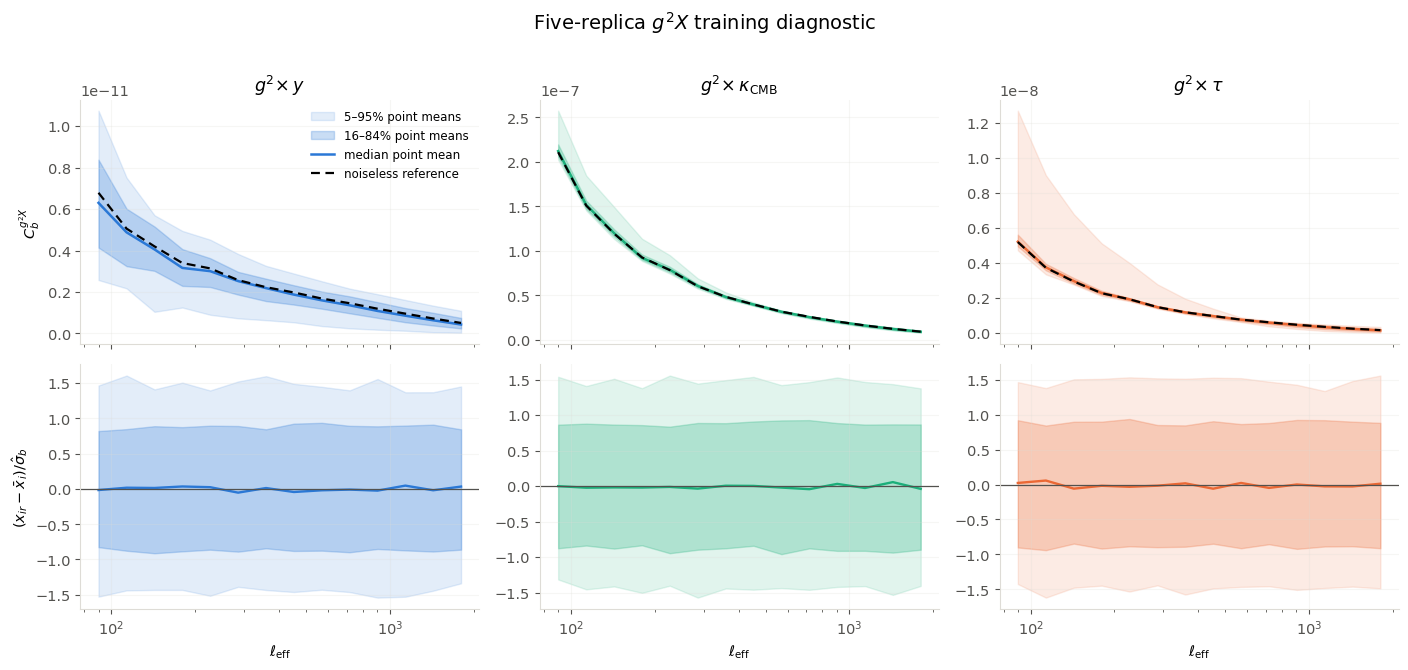

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14.2, 6.6), sharex="col")
for column, probe in enumerate(["g2y", "g2kappa", "g2tau"]):
    idx = G2_BLOCKS[probe]
    point_q = np.percentile(g2_point_means[:, idx], [5, 16, 50, 84, 95], axis=0)
    ax = axes[0, column]
    ax.fill_between(g2_ell, point_q[0], point_q[4], color=G2_COLORS[probe],
                    alpha=.13, label="5–95% point means")
    ax.fill_between(g2_ell, point_q[1], point_q[3], color=G2_COLORS[probe],
                    alpha=.25, label="16–84% point means")
    ax.plot(g2_ell, point_q[2], color=G2_COLORS[probe], lw=1.8, label="median point mean")
    ax.plot(g2_ell, g2_observation[idx], color="black", lw=1.6, ls=(0, (4, 2.5)),
            label="noiseless reference")
    ax.set_title(G2_NAMES[probe]); ax.grid(alpha=.25, color=GRID)
    if column == 0:
        ax.set_ylabel(r"$C_b^{g^2 X}$")
        ax.legend(frameon=False, fontsize=8.5)

    sigma = np.sqrt(np.diag(g2_covariance)[idx])
    standardized = g2_residuals[:, idx] / sigma[None, :]
    noise_q = np.percentile(standardized, [5, 16, 50, 84, 95], axis=0)
    ax = axes[1, column]
    ax.fill_between(g2_ell, noise_q[0], noise_q[4], color=G2_COLORS[probe], alpha=.13)
    ax.fill_between(g2_ell, noise_q[1], noise_q[3], color=G2_COLORS[probe], alpha=.25)
    ax.plot(g2_ell, noise_q[2], color=G2_COLORS[probe], lw=1.7)
    ax.axhline(0, color=INK2, lw=.9)
    ax.set_xscale("log"); ax.set_xlabel(r"$\ell_{\rm eff}$")
    ax.grid(alpha=.25, color=GRID)
    if column == 0:
        ax.set_ylabel(r"$(x_{ir}-\bar x_i)/\hat\sigma_b$")
fig.suptitle(r"Five-replica $g^2X$ training diagnostic", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(G2_FIG_DIR / "g2x_pilot_training_spread.png", dpi=180, bbox_inches="tight")
plt.show()


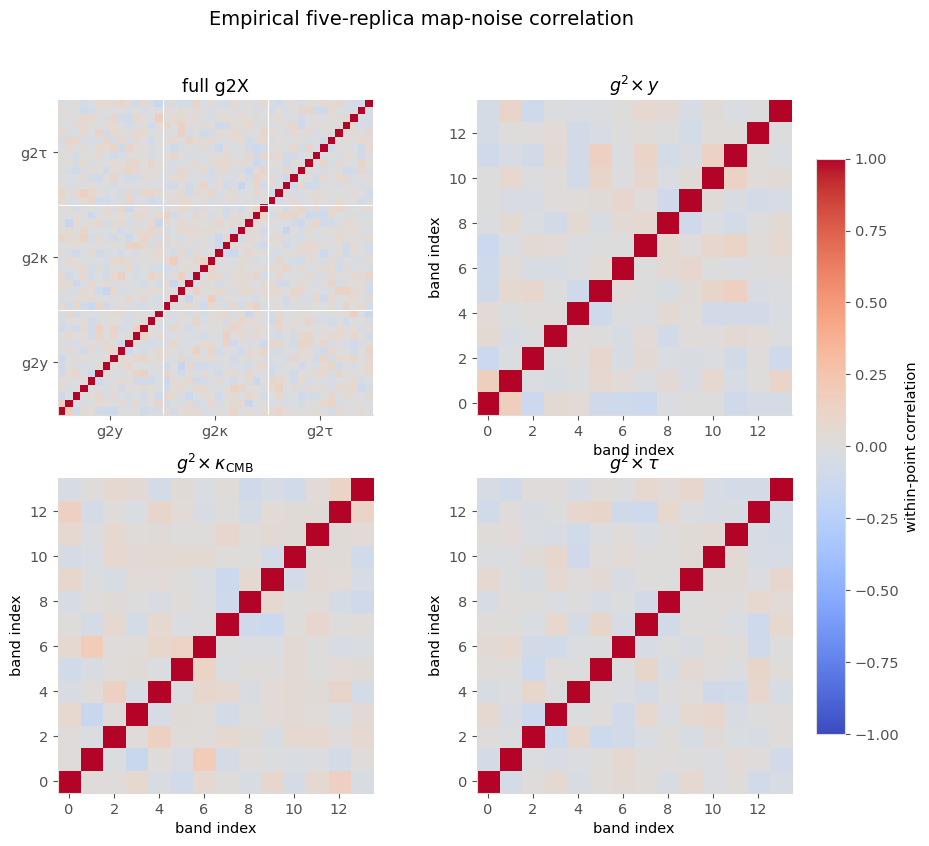

In [10]:
g2_sigma = np.sqrt(np.diag(g2_covariance))
g2_correlation = g2_covariance / np.outer(g2_sigma, g2_sigma)
fig, axes = plt.subplots(2, 2, figsize=(10.6, 9.0))
panels = [("all", np.arange(42)), ("g2y", G2_BLOCKS["g2y"]),
          ("g2kappa", G2_BLOCKS["g2kappa"]), ("g2tau", G2_BLOCKS["g2tau"])]
for ax, (probe, idx) in zip(axes.flat, panels):
    image = ax.imshow(g2_correlation[np.ix_(idx, idx)], vmin=-1, vmax=1,
                      cmap="coolwarm", origin="lower")
    ax.set_title("full g2X" if probe == "all" else G2_NAMES[probe])
    if probe == "all":
        ax.set_xticks([6.5, 20.5, 34.5], ["g2y", "g2κ", "g2τ"])
        ax.set_yticks([6.5, 20.5, 34.5], ["g2y", "g2κ", "g2τ"])
        for boundary in (13.5, 27.5):
            ax.axhline(boundary, color="white", lw=.8)
            ax.axvline(boundary, color="white", lw=.8)
    else:
        ax.set_xlabel("band index"); ax.set_ylabel("band index")
fig.colorbar(image, ax=axes, fraction=.035, pad=.03, label="within-point correlation")
fig.suptitle("Empirical five-replica map-noise correlation", y=.98, fontsize=14)
fig.savefig(G2_FIG_DIR / "g2x_pilot_noise_correlation.png", dpi=180, bbox_inches="tight")
plt.show()


### Score-compression support check

Each panel shows the five compressed training coordinates and the noiseless observed
score. A clearly isolated diamond means the observation lies outside the simulator
summary cloud; that is a pilot failure even if the resulting posterior looks smooth.


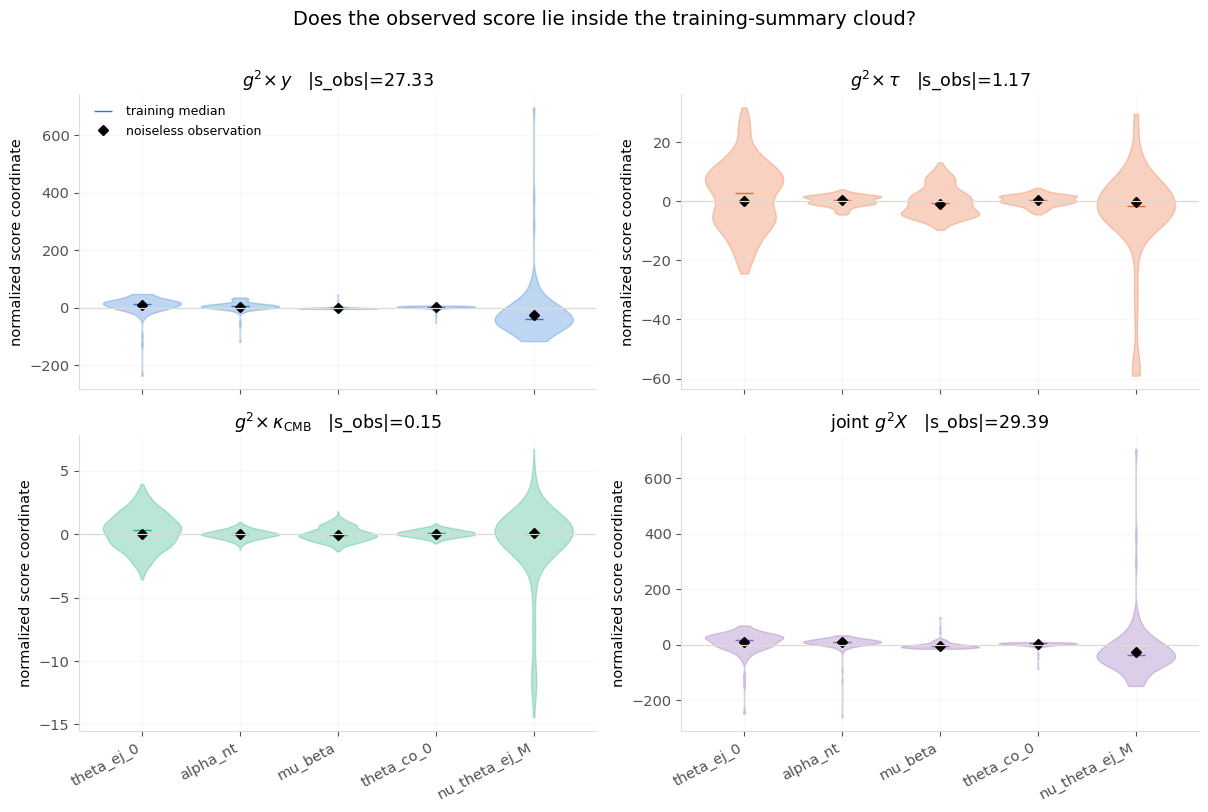

In [11]:
def g2_score(probe, vectors):
    idx = np.asarray(g2_contract[f"indices_{probe}"], dtype=int)
    chol = np.asarray(g2_contract[f"cholesky_{probe}"])
    operator = np.asarray(g2_contract[f"operator_{probe}"])
    reference = np.asarray(g2_contract[f"reference_prediction_{probe}"])
    values = np.atleast_2d(vectors)[:, idx]
    whitened = np.linalg.solve(chol, (values - reference[None, :]).T)
    return (operator @ whitened).T

finite_u_rows = np.all(np.isfinite(np.asarray(g2_train["u"])), axis=1)
fig, axes = plt.subplots(2, 2, figsize=(12.2, 8.0), sharex=True)
for ax, probe in zip(axes.flat, G2_PROBES):
    score_rows = g2_score(probe, np.asarray(g2_train["x"])[finite_u_rows])
    score_obs = np.asarray(g2_contract[f"observed_score_{probe}"])
    violins = ax.violinplot([score_rows[:, j] for j in range(5)],
                            positions=np.arange(5), showextrema=False, widths=.8)
    for body in violins["bodies"]:
        body.set_facecolor(G2_COLORS[probe]); body.set_edgecolor(G2_COLORS[probe])
        body.set_alpha(.30)
    ax.plot(np.arange(5), np.median(score_rows, axis=0), "_", ms=13,
            color=G2_COLORS[probe], label="training median")
    ax.plot(np.arange(5), score_obs, "D", ms=5.5, color="black",
            label="noiseless observation")
    ax.axhline(0, color=GRID, lw=.9)
    ax.set_title(f"{G2_NAMES[probe]}   |s_obs|={np.linalg.norm(score_obs):.2f}")
    ax.set_xticks(np.arange(5), G2_PARAM_NAMES, rotation=28, ha="right")
    ax.set_ylabel("normalized score coordinate")
    ax.grid(alpha=.22, color=GRID)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Does the observed score lie inside the training-summary cloud?", y=1.01,
             fontsize=14)
fig.tight_layout()
fig.savefig(G2_FIG_DIR / "g2x_pilot_score_support.png", dpi=180, bbox_inches="tight")
plt.show()


### Network-seed stability

The plotted quantity is each network posterior mean minus the pooled mean, divided by
the pooled posterior standard deviation. It diagnoses estimator instability; it is not
a coverage statistic.


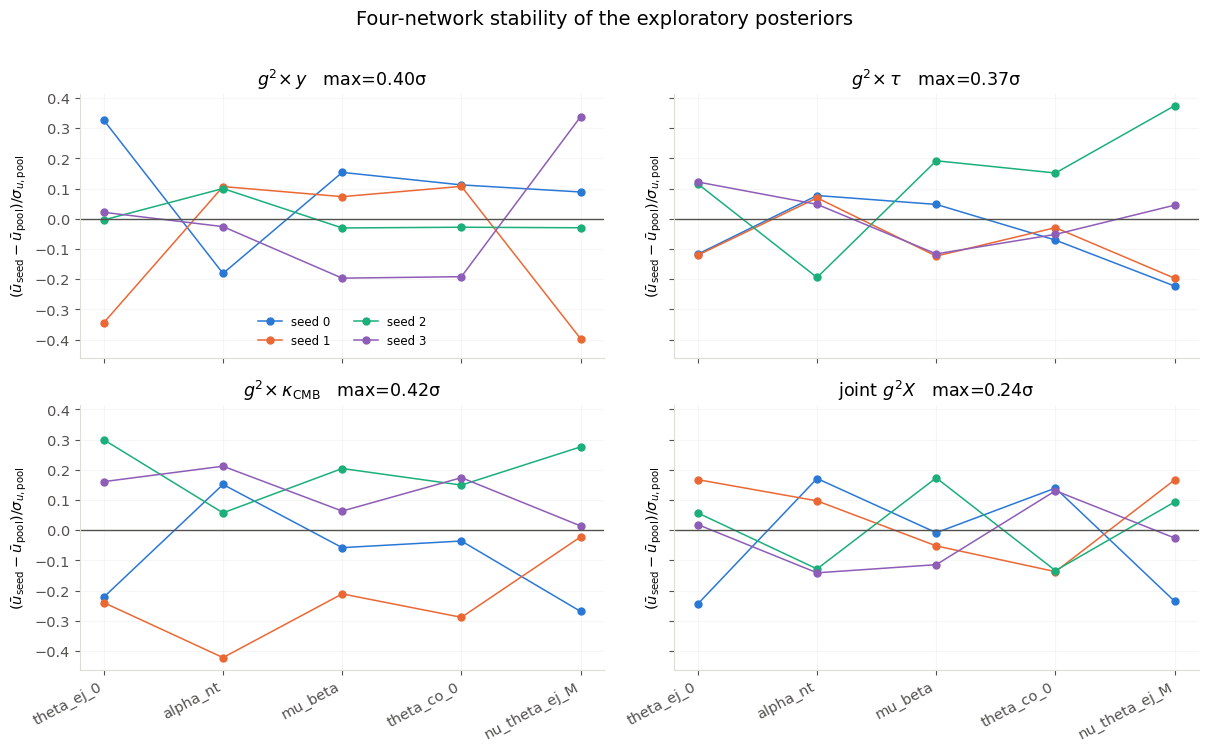

In [12]:
seed_palette = [BLUE, ORANGE, GREEN, "#8e5db7"]
fig, axes = plt.subplots(2, 2, figsize=(12.2, 7.4), sharex=True, sharey=True)
for ax, probe in zip(axes.flat, G2_PROBES):
    post = g2_posts[probe]
    man = g2_post_man[probe]
    pooled_u = np.asarray(post["u"])
    pooled_mean = pooled_u.mean(axis=0)
    pooled_sd = pooled_u.std(axis=0, ddof=1)
    for seed in range(man["network_seeds"]):
        seed_u = np.asarray(post[f"u_seed_{seed}"])
        departure = (seed_u.mean(axis=0) - pooled_mean) / pooled_sd
        ax.plot(np.arange(5), departure, "o-", lw=1.1, ms=5,
                color=seed_palette[seed % len(seed_palette)], label=f"seed {seed}")
    ax.axhline(0, color=INK2, lw=1)
    ax.set_title(f"{G2_NAMES[probe]}   max={man['max_seed_departure_sigma']:.2f}σ")
    ax.set_xticks(np.arange(5), G2_PARAM_NAMES, rotation=28, ha="right")
    ax.set_ylabel(r"$(\bar u_{\rm seed}-\bar u_{\rm pool})/\sigma_{u,{\rm pool}}$")
    ax.grid(alpha=.25, color=GRID)
axes[0, 0].legend(frameon=False, ncol=2, fontsize=8.5)
fig.suptitle("Four-network stability of the exploratory posteriors", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(G2_FIG_DIR / "g2x_pilot_seed_stability.png", dpi=180, bbox_inches="tight")
plt.show()


### Probe-by-probe and joint posterior contours

These four posteriors use the same (g^2X) simulator but different vector blocks.
Open circles show the 104 physical design points and dashed lines show the generating
point. They must not be overlaid with the existing two-point HMC/SBI contours as though
they were the same likelihood.


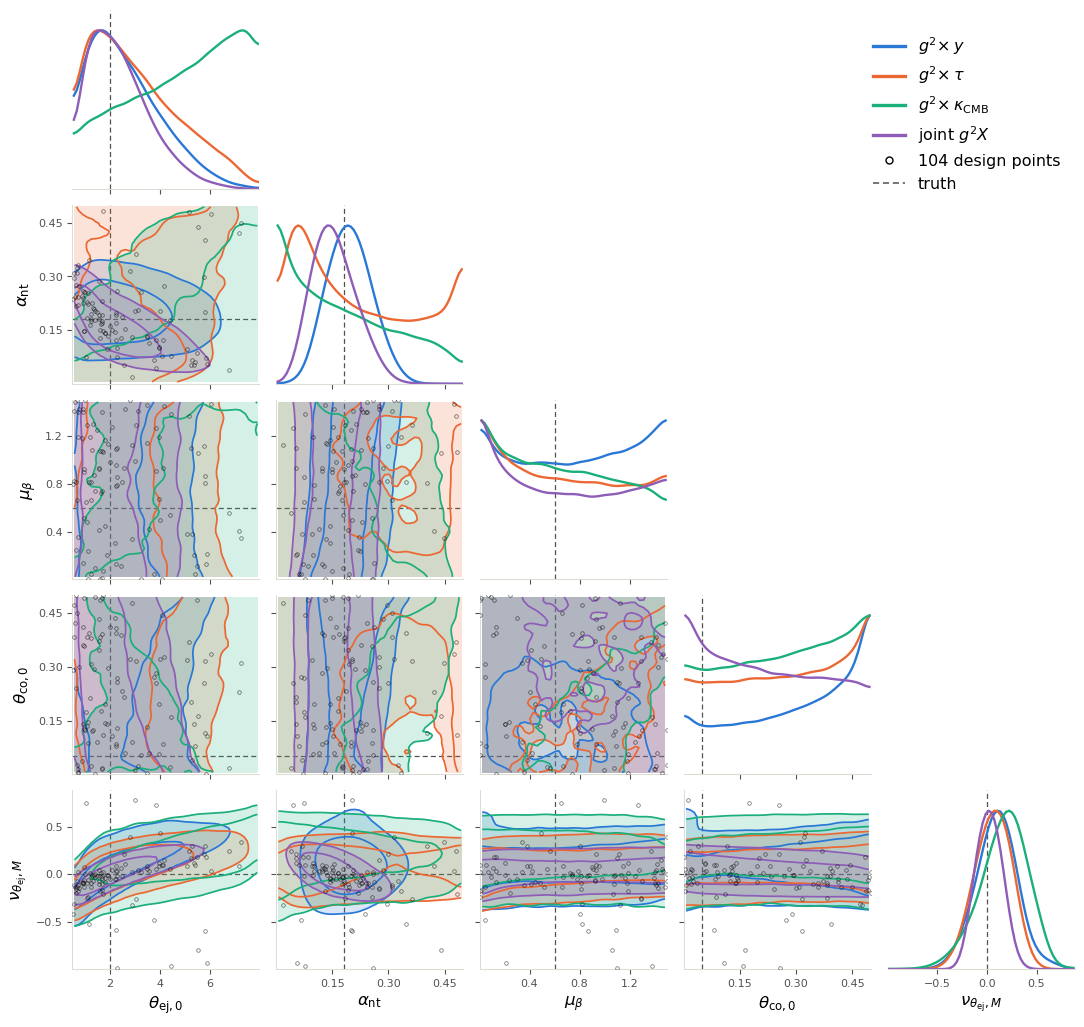

In [13]:
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

def g2_triangle(chains, colors, names, design_points, truth):
    n, bins_1d, smooth_1d, bins_2d, smooth_2d = 5, 64, 2.4, 44, 1.35
    prior_low = np.asarray(g2_contract_man["prior_low"])
    prior_high = np.asarray(g2_contract_man["prior_high"])
    lo, hi = np.empty(n), np.empty(n)
    for j in range(n):
        q = np.concatenate([np.percentile(chain[:, j], [0.3, 99.7])
                            for chain in chains])
        q = np.r_[q, design_points[:, j], truth[j]]
        pad = .06 * max(q.max() - q.min(), np.finfo(float).eps)
        lo[j] = max(prior_low[j], q.min() - pad)
        hi[j] = min(prior_high[j], q.max() + pad)

    fig, axes = plt.subplots(n, n, figsize=(11.2, 10.6))
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if j > i:
                ax.axis("off"); continue
            if i == j:
                for chain, color in zip(chains, colors):
                    density, edges = np.histogram(chain[:, j], bins=bins_1d,
                                                  range=(lo[j], hi[j]), density=True)
                    density = gaussian_filter(density, smooth_1d)
                    centres = .5 * (edges[:-1] + edges[1:])
                    if density.max() > 0:
                        ax.plot(centres, density / density.max(), color=color, lw=1.7)
                ax.set_ylim(0, 1.13); ax.set_yticks([])
                ax.spines["left"].set_visible(False)
            else:
                for order, (chain, color) in enumerate(zip(chains, colors)):
                    hist, xedge, yedge = np.histogram2d(
                        chain[:, j], chain[:, i], bins=bins_2d,
                        range=[[lo[j], hi[j]], [lo[i], hi[i]]])
                    hist = gaussian_filter(hist.T, smooth_2d)
                    if hist.max() <= 0:
                        continue
                    flat = np.sort(hist.ravel())[::-1]
                    cumulative = np.cumsum(flat) / flat.sum()
                    levels = sorted({float(flat[min(int(np.searchsorted(cumulative, frac)),
                                                    flat.size - 1)])
                                     for frac in (.68, .95)})
                    xc, yc = .5 * (xedge[:-1] + xedge[1:]), .5 * (yedge[:-1] + yedge[1:])
                    ax.contourf(xc, yc, hist, levels=levels + [hist.max() * 1.001],
                                colors=color, alpha=.18, zorder=1 + order)
                    ax.contour(xc, yc, hist, levels=levels, colors=color,
                               linewidths=1.25, zorder=5 + order)
                ax.plot(design_points[:, j], design_points[:, i], "o", ms=2.6,
                        mfc="none", mec="black", mew=.55, alpha=.55, zorder=20)
                ax.set_ylim(lo[i], hi[i])
            ax.axvline(truth[j], color=INK2, lw=.9, ls=(0, (4, 2.5)), zorder=0)
            if i != j:
                ax.axhline(truth[i], color=INK2, lw=.9, ls=(0, (4, 2.5)), zorder=0)
            ax.set_xlim(lo[j], hi[j]); ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4, prune="both"))
            if i != j:
                ax.yaxis.set_major_locator(plt.MaxNLocator(4, prune="both"))
            if i == n - 1:
                ax.set_xlabel(G2_PARAM_LABELS[j], fontsize=12)
            else:
                ax.set_xticklabels([])
            if j == 0 and i > 0:
                ax.set_ylabel(G2_PARAM_LABELS[i], fontsize=12)
            elif j != 0:
                ax.set_yticklabels([])

    handles = [Line2D([], [], color=color, lw=2.4, label=name)
               for color, name in zip(colors, names)]
    handles += [
        Line2D([], [], color="black", marker="o", ms=5, mfc="none", ls="none",
               label="104 design points"),
        Line2D([], [], color=INK2, lw=1.1, ls=(0, (4, 2.5)), label="truth"),
    ]
    fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(.985, .975),
               frameon=False, fontsize=11.5)
    fig.subplots_adjust(left=.09, right=.985, top=.985, bottom=.08,
                        wspace=.09, hspace=.09)
    return fig

g2_chains = [np.asarray(g2_posts[probe]["theta"]) for probe in G2_PROBES]
g2_fig = g2_triangle(g2_chains, [G2_COLORS[p] for p in G2_PROBES],
                     [G2_NAMES[p] for p in G2_PROBES], g2_design_theta, g2_truth)
g2_fig.savefig(G2_FIG_DIR / "g2x_pilot_four_probe_triangle.png",
               dpi=180, bbox_inches="tight")
plt.show()


### Marginal intervals, truth pulls, and relative widths

The forest plot shows pooled 90% marginal intervals. The heatmaps summarize the same
draws using mean truth pull and 90%-interval width divided by the prior width.
A pull from one fixed observation is **not coverage**; coverage requires many held-out
observations.


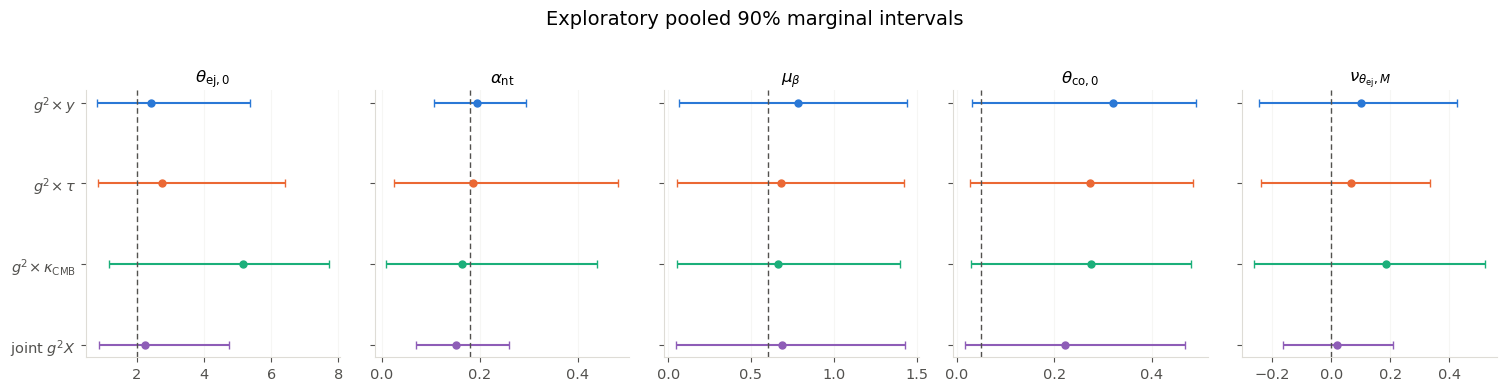

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(15.2, 3.8))
y_positions = np.arange(len(G2_PROBES))[::-1]
for parameter, ax in enumerate(axes):
    for y, probe in zip(y_positions, G2_PROBES):
        samples = np.asarray(g2_posts[probe]["theta"])[:, parameter]
        q05, median, q95 = np.percentile(samples, [5, 50, 95])
        ax.errorbar(median, y, xerr=[[median - q05], [q95 - median]], fmt="o",
                    color=G2_COLORS[probe], capsize=3, ms=5)
    ax.axvline(g2_truth[parameter], color=INK2, lw=1, ls=(0, (4, 2.5)))
    ax.set_title(G2_PARAM_LABELS[parameter], fontsize=12)
    ax.grid(axis="x", alpha=.25, color=GRID)
    ax.set_yticks(y_positions)
    if parameter == 0:
        ax.set_yticklabels([G2_NAMES[p] for p in G2_PROBES])
    else:
        ax.set_yticklabels([])
fig.suptitle("Exploratory pooled 90% marginal intervals", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(G2_FIG_DIR / "g2x_pilot_marginal_intervals.png",
            dpi=180, bbox_inches="tight")
plt.show()


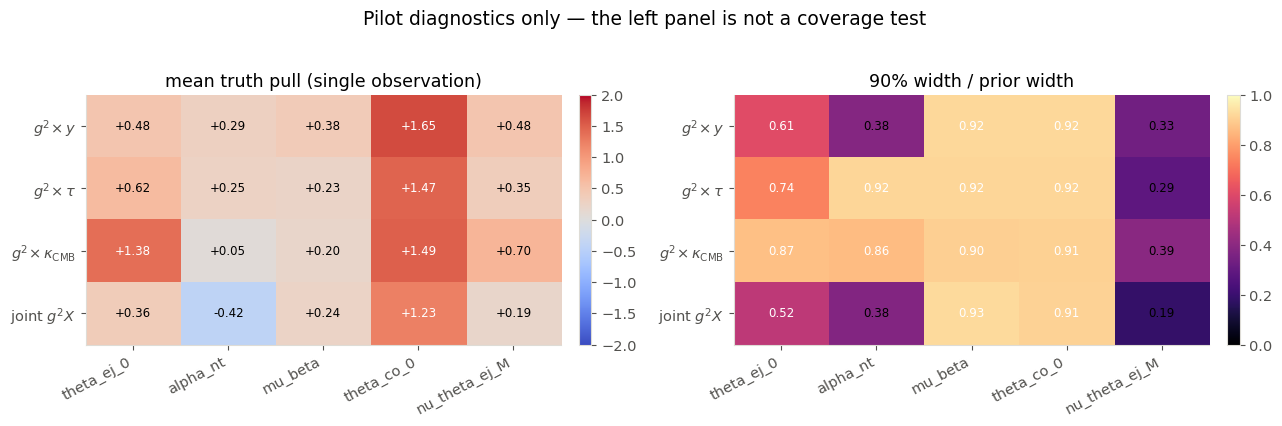

probe     parameter              q05    median       q95     pull   w90/prior
g2y       theta_ej_0          0.8208    2.4178    5.3745   +0.476       0.607
g2y       alpha_nt            0.1053    0.1947    0.2949   +0.286       0.379
g2y       mu_beta             0.0662    0.7840    1.4416   +0.381       0.920
g2y       theta_co_0          0.0317    0.3214    0.4914   +1.648       0.921
g2y       nu_theta_ej_M      -0.2433    0.1021    0.4250   +0.482       0.334
g2tau     theta_ej_0          0.8474    2.7482    6.4007   +0.625       0.740
g2tau     alpha_nt            0.0239    0.1864    0.4819   +0.252       0.916
g2tau     mu_beta             0.0516    0.6792    1.4231   +0.228       0.917
g2tau     theta_co_0          0.0279    0.2741    0.4853   +1.469       0.917
g2tau     nu_theta_ej_M      -0.2386    0.0689    0.3358   +0.352       0.287
g2kappa   theta_ej_0          1.1827    5.1475    7.7068   +1.381       0.870
g2kappa   alpha_nt            0.0090    0.1639    0.4395   +0.05

In [15]:
prior_low = np.asarray(g2_contract_man["prior_low"])
prior_high = np.asarray(g2_contract_man["prior_high"])
pull = np.empty((len(G2_PROBES), 5))
width_fraction = np.empty_like(pull)
for row, probe in enumerate(G2_PROBES):
    samples = np.asarray(g2_posts[probe]["theta"])
    pull[row] = (samples.mean(axis=0) - g2_truth) / samples.std(axis=0, ddof=1)
    q05, q95 = np.percentile(samples, [5, 95], axis=0)
    width_fraction[row] = (q95 - q05) / (prior_high - prior_low)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.1))
pull_limit = max(1.0, float(np.ceil(np.max(np.abs(pull)) * 2) / 2))
images = [
    axes[0].imshow(pull, cmap="coolwarm", vmin=-pull_limit, vmax=pull_limit,
                   aspect="auto"),
    axes[1].imshow(width_fraction, cmap="magma", vmin=0, vmax=1, aspect="auto"),
]
titles = ["mean truth pull (single observation)", "90% width / prior width"]
formats = ["{:+.2f}", "{:.2f}"]
for ax, image, title, formatter, values in zip(
        axes, images, titles, formats, [pull, width_fraction]):
    ax.set_title(title)
    ax.set_xticks(np.arange(5), G2_PARAM_NAMES, rotation=28, ha="right")
    ax.set_yticks(np.arange(len(G2_PROBES)), [G2_NAMES[p] for p in G2_PROBES])
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, formatter.format(values[i, j]), ha="center", va="center",
                    fontsize=8.5,
                    color="white" if abs(values[i, j]) > .55 * np.max(np.abs(values))
                    else "black")
    fig.colorbar(image, ax=ax, fraction=.045, pad=.035)
fig.suptitle("Pilot diagnostics only — the left panel is not a coverage test",
             y=1.03, fontsize=13.5)
fig.tight_layout()
fig.savefig(G2_FIG_DIR / "g2x_pilot_truth_pull_and_width.png",
            dpi=180, bbox_inches="tight")
plt.show()

print(f"{'probe':9s} {'parameter':16s} {'q05':>9s} {'median':>9s} "
      f"{'q95':>9s} {'pull':>8s} {'w90/prior':>11s}")
for row, probe in enumerate(G2_PROBES):
    samples = np.asarray(g2_posts[probe]["theta"])
    q05, median, q95 = np.percentile(samples, [5, 50, 95], axis=0)
    for j, parameter in enumerate(G2_PARAM_NAMES):
        print(f"{probe:9s} {parameter:16s} {q05[j]:9.4f} {median[j]:9.4f} "
              f"{q95[j]:9.4f} {pull[row, j]:+8.3f} "
              f"{width_fraction[row, j]:11.3f}")


**How to read this pilot.** Treat it as successful only as an engineering/statistical
smoke test: the observation should lie within the compressed training cloud, the four
network posteriors should not split into incompatible locations, and the probe/joint
contours should be numerically well behaved. None of those checks establishes calibrated
coverage. The next scientific step is to rebuild the same product with 64 map-level noise
realisations per point and repeat the four-network ensemble.
